# Partie 4 — Modèles Classiques de Machine Learning

## De quoi parle ce notebook ?

Maintenant que nos données sont prêtes, on va entraîner nos premiers modèles. On compare trois approches classiques du machine learning, du plus simple au plus complexe :

1. **Linear Regression** — notre baseline, le modèle de référence le plus simple
2. **Random Forest** — un ensemble d'arbres de décision
3. **XGBoost** — le modèle le plus puissant pour les données tabulaires

Pour chaque modèle on fait à la fois de la **régression** (prédire le rendement exact de demain) et de la **classification** (prédire si ça monte ou ça baisse demain).

### Règle importante — pas de mélange temporel
On coupe les données de façon **strictement chronologique**. Le modèle apprend sur le passé et est évalué sur le futur. On n'utilise jamais de `train_test_split` aléatoire sur des séries temporelles.

---
## Etape 0 — Chargement des données et split temporel

On recharge le dataset du notebook 03 et on définit notre découpage chronologique :
- **Train** : 2020 → fin 2022 (le modèle apprend sur cette période)
- **Validation** : 2023 (on ajuste les hyperparamètres sur cette période)
- **Test** : 2024 → aujourd'hui (évaluation finale — le modèle ne touche jamais à ces données pendant l'entraînement)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)
from xgboost import XGBRegressor, XGBClassifier

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')

# Charger le dataset final du notebook 03
features_df = pd.read_parquet('data/03_features.parquet')

# Charger la liste des features
with open('data/feature_cols.txt', 'r') as f:
    FEATURE_COLS = [line.strip() for line in f.readlines()]

print('Données chargées!')
print(f' Shape : {features_df.shape}')
print(f'Features : {len(FEATURE_COLS)}')
print(f'Dates : {features_df["date"].min().date()} à {features_df["date"].max().date()}')
print(f'Stocks : {features_df["ticker"].nunique()}')
print(f'Secteurs: {list(features_df["sector"].unique())}')

Données chargées!
 Shape : (73647, 63)
Features : 47
Dates : 2020-03-16 à 2026-03-09
Stocks : 49
Secteurs: ['Technology', 'Healthcare', 'Finance', 'Industrials', 'Energy']


In [2]:
# Découpage chronologique strict
# JAMAIS de shuffle sur des séries temporelles !

TRAIN_END = '2022-12-31'
VAL_END   = '2023-12-31'

train_df = features_df[features_df['date'] <= TRAIN_END]
val_df   = features_df[(features_df['date'] > TRAIN_END) & (features_df['date'] <= VAL_END)]
test_df  = features_df[features_df['date'] > VAL_END]

# Features et targets
X_train = train_df[FEATURE_COLS]
X_val   = val_df[FEATURE_COLS]
X_test  = test_df[FEATURE_COLS]

# Régression — prédire le rendement exact
y_train_reg = train_df['target_return']
y_val_reg   = val_df['target_return']
y_test_reg  = test_df['target_return']

# Classification — prédire la direction (1=hausse, 0=baisse)
y_train_clf = train_df['target_direction']
y_val_clf   = val_df['target_direction']
y_test_clf  = test_df['target_direction']

print('Split temporel effectué!')
print(f'Train : {train_df["date"].min().date()} → {train_df["date"].max().date()} ({len(train_df):,} lignes)')
print(f'Validation : {val_df["date"].min().date()} → {val_df["date"].max().date()} ({len(val_df):,} lignes)')
print(f'Test: {test_df["date"].min().date()} → {test_df["date"].max().date()} ({len(test_df):,} lignes)')
print()
print(f'Distribution target_direction (train) :')
print(f'Hausse : {(y_train_clf == 1).mean():.1%}')
print(f'Baisse : {(y_train_clf == 0).mean():.1%}')

Split temporel effectué!
Train : 2020-03-16 → 2022-12-30 (34,594 lignes)
Validation : 2023-01-03 → 2023-12-29 (12,250 lignes)
Test: 2024-01-02 → 2026-03-09 (26,803 lignes)

Distribution target_direction (train) :
Hausse : 51.5%
Baisse : 48.5%



## Etape 1 — Modèle Baseline (Linear Regression)

Avant de tester des modèles complexes, on commence toujours par le modèle le plus simple possible. C'est ce qu'on appelle le **baseline** — notre référence minimale.

Si un modèle complexe comme XGBoost ne fait pas mieux que la régression linéaire, c'est qu'il ne sert à rien d'utiliser quelque chose de plus compliqué.

On utilise :
- **Linear Regression** pour la partie régression
- **Logistic Regression** pour la partie classification

On normalise aussi les features avec un **StandardScaler** car la régression linéaire est sensible aux différences d'échelle entre les variables.

In [3]:
# Normalisation des features
# Important pour la régression linéaire qui est sensible aux échelles
# On fit le scaler UNIQUEMENT sur le train — jamais sur val ou test (anti-leakage)
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Normalisation effectuée!')
print(f'Moyenne features train (doit être ~0) : {X_train_scaled.mean():.4f}')
print(f'Std features train (doit être ~1)     : {X_train_scaled.std():.4f}')

Normalisation effectuée!
Moyenne features train (doit être ~0) : -0.0000
Std features train (doit être ~1)     : 1.0000


In [4]:
# --- REGRESSION LINEAIRE ---
print('Entraînement Linear Regression')
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_train_reg)

# Prédictions
y_pred_lr_val  = lr_reg.predict(X_val_scaled)
y_pred_lr_test = lr_reg.predict(X_test_scaled)

# Métriques régression
rmse_lr_val  = np.sqrt(mean_squared_error(y_val_reg, y_pred_lr_val))
rmse_lr_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_test))
mae_lr_val   = mean_absolute_error(y_val_reg, y_pred_lr_val)
mae_lr_test  = mean_absolute_error(y_test_reg, y_pred_lr_test)

print(f'RMSE Validation: {rmse_lr_val:.5f}')
print(f'RMSE Test: {rmse_lr_test:.5f}')
print(f' MAE Validation : {mae_lr_val:.5f}')
print(f' MAE Test : {mae_lr_test:.5f}')

Entraînement Linear Regression
RMSE Validation: 0.01715
RMSE Test: 0.02507
 MAE Validation : 0.01261
 MAE Test : 0.01981


In [5]:
# --- LOGISTIC REGRESSION (classification) ---
print('Entraînement Logistic Regression (classification)...')
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train_scaled, y_train_clf)

# Prédictions
y_pred_lr_clf_val = lr_clf.predict(X_val_scaled)
y_pred_lr_clf_test = lr_clf.predict(X_test_scaled)
y_proba_lr_val = lr_clf.predict_proba(X_val_scaled)[:, 1]
y_proba_lr_test= lr_clf.predict_proba(X_test_scaled)[:, 1]

# Métriques classification
acc_lr_val = accuracy_score(y_val_clf, y_pred_lr_clf_val)
acc_lr_test= accuracy_score(y_test_clf, y_pred_lr_clf_test)
f1_lr_val= f1_score(y_val_clf, y_pred_lr_clf_val)
f1_lr_test= f1_score(y_test_clf, y_pred_lr_clf_test)
auc_lr_val = roc_auc_score(y_val_clf, y_proba_lr_val)
auc_lr_test = roc_auc_score(y_test_clf, y_proba_lr_test)

print(f'Accuracy Validation: {acc_lr_val:.4f}')
print(f'Accuracy Test : {acc_lr_test:.4f}')
print(f'F1 Validation: {f1_lr_val:.4f}')
print(f'F1 Test : {f1_lr_test:.4f}')
print(f'AUC Validation: {auc_lr_val:.4f}')
print(f'AUC Test: {auc_lr_test:.4f}')

Entraînement Logistic Regression (classification)...
Accuracy Validation: 0.4860
Accuracy Test : 0.4710
F1 Validation: 0.0798
F1 Test : 0.0000
AUC Validation: 0.4918
AUC Test: 0.5007



## Etape 2 — Random Forest

Le Random Forest est un ensemble de plusieurs arbres de décision qui votent ensemble pour donner une prédiction. Il est beaucoup plus puissant que la régression linéaire car il capture les **relations non-linéaires** entre les features.

Pour éviter l'overfitting on contrôle deux paramètres importants :
- **max_depth** : limite la profondeur de chaque arbre — un arbre trop profond mémorise les données d'entraînement
- **min_samples_leaf** : impose un nombre minimum d'observations dans chaque feuille — évite les splits trop spécifiques

On compare toujours les scores **train vs validation** pour détecter l'overfitting — si le score train est beaucoup plus élevé que le score validation, le modèle a overfit.

In [6]:
print('Entraînement Random Forest Regression')

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,           # Limite la profondeur pour éviter l'overfitting
    min_samples_leaf=50,    # Minimum 50 observations par feuille
    n_jobs=-1,              # Utilise tous les coeurs disponibles
    random_state=42
)
rf_reg.fit(X_train, y_train_reg)

# Prédictions
y_pred_rf_train= rf_reg.predict(X_train)
y_pred_rf_val = rf_reg.predict(X_val)
y_pred_rf_test= rf_reg.predict(X_test)

# Métriques
rmse_rf_train= np.sqrt(mean_squared_error(y_train_reg, y_pred_rf_train))
rmse_rf_val= np.sqrt(mean_squared_error(y_val_reg, y_pred_rf_val))
rmse_rf_test= np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_test))

print(f'\n  RMSE Train : {rmse_rf_train:.5f}')
print(f'RMSE Validation: {rmse_rf_val:.5f}')
print(f'RMSE Test: {rmse_rf_test:.5f}')
print()
if rmse_rf_train < rmse_rf_val * 0.8:
    print('Possible overfitting détecté (train bien meilleur que validation)')
else:
    print('Pas d overfitting détecté (train et validation proches)')

Entraînement Random Forest Regression

  RMSE Train : 0.02028
RMSE Validation: 0.01665
RMSE Test: 0.01792

Pas d overfitting détecté (train et validation proches)


In [7]:
# --- RANDOM FOREST CLASSIFICATION ---
print('Entraînement Random Forest Classification...')

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42
)
rf_clf.fit(X_train, y_train_clf)

# Prédictions
y_pred_rf_clf_train= rf_clf.predict(X_train)
y_pred_rf_clf_val= rf_clf.predict(X_val)
y_pred_rf_clf_test = rf_clf.predict(X_test)
y_proba_rf_val = rf_clf.predict_proba(X_val)[:, 1]
y_proba_rf_test = rf_clf.predict_proba(X_test)[:, 1]

# Métriques
acc_rf_train= accuracy_score(y_train_clf, y_pred_rf_clf_train)
acc_rf_val  = accuracy_score(y_val_clf, y_pred_rf_clf_val)
acc_rf_test= accuracy_score(y_test_clf, y_pred_rf_clf_test)
f1_rf_val = f1_score(y_val_clf, y_pred_rf_clf_val)
f1_rf_test= f1_score(y_test_clf, y_pred_rf_clf_test)
auc_rf_val = roc_auc_score(y_val_clf, y_proba_rf_val)
auc_rf_test = roc_auc_score(y_test_clf, y_proba_rf_test)

print(f'\n  Accuracy Train: {acc_rf_train:.4f}')
print(f'Accuracy Validation: {acc_rf_val:.4f}')
print(f'Accuracy Test  : {acc_rf_test:.4f}')
print(f'F1 Test : {f1_rf_test:.4f}')
print(f'AUC Test : {auc_rf_test:.4f}')
print()
if acc_rf_train > acc_rf_val + 0.05:
    print('Possible overfitting détecté (train bien meilleur que validation)')
else:
    print('Pas d overfitting détecté')

Entraînement Random Forest Classification...

  Accuracy Train: 0.7298
Accuracy Validation: 0.4823
Accuracy Test  : 0.4713
F1 Test : 0.0401
AUC Test : 0.4920

Possible overfitting détecté (train bien meilleur que validation)



## Correction de l'overfitting — Random Forest

On a détecté un overfitting important : 73% sur le train vs 48% sur la validation. Le modèle a mémorisé les données d'entraînement.

Pour corriger ça on va :
- Réduire `max_depth` de 10 à 5 — arbres moins profonds
- Augmenter `min_samples_leaf` de 50 à 100 — feuilles plus larges
- Augmenter `min_samples_split` — splits moins agressifs

L'objectif n'est pas d'avoir le meilleur score sur le train, mais le meilleur score sur des données jamais vues (validation et test).

In [8]:
print('Réentraînement Random Forest avec régularisation plus forte.')

rf_clf_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,             
    min_samples_leaf=100,    
    min_samples_split=200,   
    max_features='sqrt',     
    n_jobs=-1,
    random_state=42
)
rf_clf_v2.fit(X_train, y_train_clf)

# Prédictions
y_pred_rf_v2_train= rf_clf_v2.predict(X_train)
y_pred_rf_v2_val = rf_clf_v2.predict(X_val)
y_pred_rf_v2_test= rf_clf_v2.predict(X_test)
y_proba_rf_v2_val = rf_clf_v2.predict_proba(X_val)[:, 1]
y_proba_rf_v2_test = rf_clf_v2.predict_proba(X_test)[:, 1]

# Métriques
acc_rf_v2_train= accuracy_score(y_train_clf, y_pred_rf_v2_train)
acc_rf_v2_val= accuracy_score(y_val_clf, y_pred_rf_v2_val)
acc_rf_v2_test = accuracy_score(y_test_clf, y_pred_rf_v2_test)

f1_rf_v2_test = f1_score(y_test_clf, y_pred_rf_v2_test) 

auc_rf_v2_val= roc_auc_score(y_val_clf, y_proba_rf_v2_val)
auc_rf_v2_test = roc_auc_score(y_test_clf, y_proba_rf_v2_test)

print(f'\n Accuracy Train : {acc_rf_v2_train:.4f}')
print(f' Accuracy Validation: {acc_rf_v2_val:.4f}')
print(f'Accuracy Test : {acc_rf_v2_test:.4f}')
print(f' F1 Test : {f1_rf_v2_test:.4f}') 
print(f'AUC Validation: {auc_rf_v2_val:.4f}')
print(f'AUC Test: {auc_rf_v2_test:.4f}')
print()

gap = acc_rf_v2_train - acc_rf_v2_val
if gap > 0.05:
    print(f'Overfitting encore présent (gap train/val = {gap:.4f})')
else:
    print(f'Overfitting corrigé (gap train/val = {gap:.4f})')

Réentraînement Random Forest avec régularisation plus forte.

 Accuracy Train : 0.6421
 Accuracy Validation: 0.4856
Accuracy Test : 0.4705
 F1 Test : 0.0585
AUC Validation: 0.5309
AUC Test: 0.4982

Overfitting encore présent (gap train/val = 0.1565)



## Correction de l'overfitting — Random Forest v3

Le gap train/val est passé de 0.25 à 0.15 — on progresse mais ce n'est pas encore suffisant. On va pousser la régularisation encore plus loin avec des arbres très contraints.

C'est un comportement typique du Random Forest sur des données financières — les marchés sont très bruités et un Random Forest a naturellement tendance à mémoriser le bruit du train. C'est pourquoi XGBoost avec régularisation explicite donne souvent de meilleurs résultats sur ce type de données.

In [9]:
print('Réentraînement Random Forest v3 — régularisation maximale')

rf_clf_v3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,              
    min_samples_leaf=200,     
    min_samples_split=400,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf_clf_v3.fit(X_train, y_train_clf)

y_pred_rf_v3_train = rf_clf_v3.predict(X_train)
y_pred_rf_v3_val   = rf_clf_v3.predict(X_val)
y_pred_rf_v3_test  = rf_clf_v3.predict(X_test)
y_proba_rf_v3_val  = rf_clf_v3.predict_proba(X_val)[:, 1]
y_proba_rf_v3_test = rf_clf_v3.predict_proba(X_test)[:, 1]

acc_rf_v3_train = accuracy_score(y_train_clf, y_pred_rf_v3_train)
acc_rf_v3_val   = accuracy_score(y_val_clf, y_pred_rf_v3_val)
acc_rf_v3_test  = accuracy_score(y_test_clf, y_pred_rf_v3_test)
f1_rf_v3_val    = f1_score(y_val_clf, y_pred_rf_v3_val)
f1_rf_v3_test   = f1_score(y_test_clf, y_pred_rf_v3_test)
auc_rf_v3_val   = roc_auc_score(y_val_clf, y_proba_rf_v3_val)
auc_rf_v3_test  = roc_auc_score(y_test_clf, y_pred_rf_v3_test)

print(f'\nAccuracy Train: {acc_rf_v3_train:.4f}')
print(f'Accuracy Validation: {acc_rf_v3_val:.4f}')
print(f'Accuracy Test: {acc_rf_v3_test:.4f}')
print(f'F1 Validation: {f1_rf_v3_val:.4f}')
print(f' F1 Test: {f1_rf_v3_test:.4f}')
print(f'AUC Validation: {auc_rf_v3_val:.4f}')
print(f'AUC Test : {auc_rf_v3_test:.4f}')
print()

gap = acc_rf_v3_train - acc_rf_v3_val
print(f'Gap train/val : {gap:.4f}')
if gap > 0.05:
    print(f'Overfitting encore présent')
    print(f'On garde ce modèle et on passe à XGBoost qui gère mieux ce problème')
else:
    print(f'Overfitting corrigé!')

best_rf_clf    = rf_clf_v3
y_pred_rf_best = y_pred_rf_v3_test
y_proba_rf_best = y_proba_rf_v3_test

Réentraînement Random Forest v3 — régularisation maximale

Accuracy Train: 0.5876
Accuracy Validation: 0.4914
Accuracy Test: 0.4823
F1 Validation: 0.0974
 F1 Test: 0.3234
AUC Validation: 0.5234
AUC Test : 0.4976

Gap train/val : 0.0962
Overfitting encore présent
On garde ce modèle et on passe à XGBoost qui gère mieux ce problème



## Etape 3 — XGBoost

XGBoost est souvent considéré comme le meilleur modèle pour les données tabulaires. Il est basé sur le **gradient boosting** — au lieu de construire des arbres indépendants comme le Random Forest, il construit les arbres **séquentiellement** en corrigeant les erreurs du modèle précédent.

Sa grande force est sa **régularisation explicite** :
- **reg_alpha** (L1) : pousse les coefficients peu importants vers zéro — sélectionne les features les plus utiles
- **reg_lambda** (L2) : pénalise les grands coefficients — réduit l'overfitting
- **early_stopping** : arrête l'entraînement automatiquement quand la performance sur la validation ne s'améliore plus

Ces mécanismes font que XGBoost est naturellement moins sujet à l'overfitting que le Random Forest sur des données financières bruitées.

In [10]:
print('Entraînement XGBoost Regression')

xgb_reg = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,       
    reg_lambda=1.0,      
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50
)

xgb_reg.fit(
    X_train, y_train_reg,
    eval_set=[(X_val, y_val_reg)],
    verbose=False
)

y_pred_xgb_train = xgb_reg.predict(X_train)
y_pred_xgb_val = xgb_reg.predict(X_val)
y_pred_xgb_test = xgb_reg.predict(X_test)

rmse_xgb_train= np.sqrt(mean_squared_error(y_train_reg, y_pred_xgb_train))
rmse_xgb_val = np.sqrt(mean_squared_error(y_val_reg, y_pred_xgb_val))
rmse_xgb_test  = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_test))
mae_xgb_test= mean_absolute_error(y_test_reg, y_pred_xgb_test)

print(f'Nombre d arbres utilisés : {xgb_reg.best_iteration}')
print(f'RMSE Train: {rmse_xgb_train:.5f}')
print(f' RMSE Validation: {rmse_xgb_val:.5f}')
print(f'RMSE Test : {rmse_xgb_test:.5f}')
print(f'MAE Test : {mae_xgb_test:.5f}')
print()
gap = rmse_xgb_train - rmse_xgb_val
if abs(gap) < rmse_xgb_val * 0.1:
    print(f' Pas d overfitting détecté')
else:
    print(f'Possible overfitting (gap = {gap:.5f})')

Entraînement XGBoost Regression
Nombre d arbres utilisés : 11
RMSE Train: 0.02224
 RMSE Validation: 0.01658
RMSE Test : 0.01787
MAE Test : 0.01271

Possible overfitting (gap = 0.00566)


In [11]:
print('Entraînement XGBoost Classification')

xgb_clf = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50,
    eval_metric='logloss'
)

xgb_clf.fit(
    X_train, y_train_clf,
    eval_set=[(X_val, y_val_clf)],
    verbose=False
)

y_pred_xgb_clf_train= xgb_clf.predict(X_train)
y_pred_xgb_clf_val= xgb_clf.predict(X_val)
y_pred_xgb_clf_test= xgb_clf.predict(X_test)
y_proba_xgb_val = xgb_clf.predict_proba(X_val)[:, 1]
y_proba_xgb_test= xgb_clf.predict_proba(X_test)[:, 1]

acc_xgb_train= accuracy_score(y_train_clf, y_pred_xgb_clf_train)
acc_xgb_val = accuracy_score(y_val_clf, y_pred_xgb_clf_val)
acc_xgb_test= accuracy_score(y_test_clf, y_pred_xgb_clf_test)
f1_xgb_val = f1_score(y_val_clf, y_pred_xgb_clf_val)
f1_xgb_test = f1_score(y_test_clf, y_pred_xgb_clf_test)
auc_xgb_val= roc_auc_score(y_val_clf, y_proba_xgb_val)
auc_xgb_test= roc_auc_score(y_test_clf, y_proba_xgb_test)

print(f'Nombre d arbres utilisés: {xgb_clf.best_iteration}')
print(f'  Accuracy Train {acc_xgb_train:.4f}')
print(f'  Accuracy Validatio: {acc_xgb_val:.4f}')
print(f'  Accuracy Test : {acc_xgb_test:.4f}')
print(f' F1 Validation: {f1_xgb_val:.4f}')
print(f'  F1 Test : {f1_xgb_test:.4f}')
print(f'  AUC Validation : {auc_xgb_val:.4f}')
print(f'AUC Test: {auc_xgb_test:.4f}')
print()
gap = acc_xgb_train - acc_xgb_val
if gap > 0.05:
    print(f' Overfitting détecté (gap = {gap:.4f})')
else:
    print(f'  Pas d overfitting (gap = {gap:.4f})')

Entraînement XGBoost Classification
Nombre d arbres utilisés: 11
  Accuracy Train 0.5324
  Accuracy Validatio: 0.5412
  Accuracy Test : 0.5174
 F1 Validation: 0.5886
  F1 Test : 0.6598
  AUC Validation : 0.5419
AUC Test: 0.4999

  Pas d overfitting (gap = -0.0088)



## Etape 4 — Walk-Forward Validation

Le simple split train/val/test qu'on a fait jusqu'ici est une bonne première approche, mais on peut faire mieux avec la **walk-forward validation**.

L'idée est simple : on simule ce qui se passerait en conditions réelles.
- On entraîne sur une fenêtre de données passées
- On prédit sur la période suivante
- On avance la fenêtre d'un pas
- On répète

Cela nous donne plusieurs scores sur différentes périodes, ce qui prouve que notre modèle est robuste et pas juste chanceux sur une seule période de test.

On utilise `TimeSeriesSplit` de scikit-learn qui fait exactement ça de façon automatique.

In [15]:
from sklearn.model_selection import TimeSeriesSplit

print('Walk-Forward Validation avec XGBoost...')
print()

tscv = TimeSeriesSplit(n_splits=5)

wf_scores = {
    'accuracy' : [],
    'f1'       : [],
    'auc'      : [],
    'rmse'     : []
}


data_wf = features_df[features_df['date'] <= VAL_END].copy()
X_wf    = data_wf[FEATURE_COLS]
y_wf_clf = data_wf['target_direction']
y_wf_reg = data_wf['target_return']

fold = 1
for train_idx, val_idx in tscv.split(X_wf):
    X_fold_train = X_wf.iloc[train_idx]
    X_fold_val   = X_wf.iloc[val_idx]
    y_fold_train_clf = y_wf_clf.iloc[train_idx]
    y_fold_val_clf   = y_wf_clf.iloc[val_idx]
    y_fold_train_reg = y_wf_reg.iloc[train_idx]
    y_fold_val_reg   = y_wf_reg.iloc[val_idx]

    model_clf = XGBClassifier(
        n_estimators=200, learning_rate=0.01, max_depth=4,
        min_child_weight=50, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbosity=0
    )
    model_clf.fit(X_fold_train, y_fold_train_clf)
    y_fold_pred_clf   = model_clf.predict(X_fold_val)
    y_fold_proba_clf  = model_clf.predict_proba(X_fold_val)[:, 1]

    # Regression
    model_reg = XGBRegressor(
        n_estimators=200, learning_rate=0.01, max_depth=4,
        min_child_weight=50, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbosity=0
    )
    model_reg.fit(X_fold_train, y_fold_train_reg)
    y_fold_pred_reg = model_reg.predict(X_fold_val)

    acc  = accuracy_score(y_fold_val_clf, y_fold_pred_clf)
    f1   = f1_score(y_fold_val_clf, y_fold_pred_clf)
    auc  = roc_auc_score(y_fold_val_clf, y_fold_proba_clf)
    rmse = np.sqrt(mean_squared_error(y_fold_val_reg, y_fold_pred_reg))

    wf_scores['accuracy'].append(acc)
    wf_scores['f1'].append(f1)
    wf_scores['auc'].append(auc)
    wf_scores['rmse'].append(rmse)

    print(f'Fold {fold} — Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | RMSE: {rmse:.5f}')
    fold += 1

print()
print(f'  Moyenne Accuracy : {np.mean(wf_scores["accuracy"]):.4f} (+/- {np.std(wf_scores["accuracy"]):.4f})')
print(f'  Moyenne F1       : {np.mean(wf_scores["f1"]):.4f} (+/- {np.std(wf_scores["f1"]):.4f})')
print(f'  Moyenne AUC      : {np.mean(wf_scores["auc"]):.4f} (+/- {np.std(wf_scores["auc"]):.4f})')
print(f'  Moyenne RMSE     : {np.mean(wf_scores["rmse"]):.5f} (+/- {np.std(wf_scores["rmse"]):.5f})')

Walk-Forward Validation avec XGBoost...

Fold 1 — Accuracy: 0.5936 | F1: 0.6589 | AUC: 0.6346 | RMSE: 0.01898
Fold 2 — Accuracy: 0.6362 | F1: 0.6784 | AUC: 0.6924 | RMSE: 0.01952
Fold 3 — Accuracy: 0.6275 | F1: 0.6754 | AUC: 0.6721 | RMSE: 0.01751
Fold 4 — Accuracy: 0.6329 | F1: 0.6791 | AUC: 0.6905 | RMSE: 0.02262
Fold 5 — Accuracy: 0.6385 | F1: 0.6860 | AUC: 0.6979 | RMSE: 0.02003

  Moyenne Accuracy : 0.6257 (+/- 0.0165)
  Moyenne F1       : 0.6756 (+/- 0.0090)
  Moyenne AUC      : 0.6775 (+/- 0.0231)
  Moyenne RMSE     : 0.01973 (+/- 0.00167)



## Etape 5 — Comparaison finale des modèles

On résume maintenant les performances de tous les modèles dans un tableau comparatif. C'est ce tableau qu'on mettra dans le rapport final pour montrer quelle approche fonctionne le mieux.

On compare sur les métriques les plus importantes :
- **Accuracy** : pourcentage de bonnes prédictions de direction
- **F1 Score** : équilibre entre précision et rappel
- **AUC-ROC** : capacité du modèle à distinguer les hausses des baisses
- **RMSE** : erreur moyenne sur la prédiction du rendement exact

In [16]:
results = {
    'Modèle': [
        'Linear Regression (baseline)',
        'Logistic Regression (baseline)',
        'Random Forest v1 (overfit)',
        'Random Forest v3 (corrigé)',
        'XGBoost (test set)',
        'XGBoost (walk-forward avg)'
    ],
    'Accuracy': [
        '-',
        f'{acc_lr_test:.4f}',
        f'{acc_rf_test:.4f}',
        f'{acc_rf_v3_test:.4f}',
        f'{acc_xgb_test:.4f}',
        f'{np.mean(wf_scores["accuracy"]):.4f}'
    ],
    'F1 Score': [
        '-',
        f'{f1_lr_test:.4f}',
        f'{f1_rf_v3_test:.4f}',
        f'{f1_rf_v3_test:.4f}',
        f'{f1_xgb_test:.4f}',
        f'{np.mean(wf_scores["f1"]):.4f}'
    ],
    'AUC-ROC': [
        '-',
        f'{auc_lr_test:.4f}',
        f'{auc_rf_test:.4f}',
        f'{auc_rf_v3_test:.4f}',
        f'{auc_xgb_test:.4f}',
        f'{np.mean(wf_scores["auc"]):.4f}'
    ],
    'RMSE': [
        f'{rmse_lr_test:.5f}',
        '-',
        f'{rmse_rf_test:.5f}',
        '-',
        f'{rmse_xgb_test:.5f}',
        f'{np.mean(wf_scores["rmse"]):.5f}'
    ],
    'Overfitting': [
        'Non',
        'Non',
        'Oui (gap=0.25)',
        'Partiel (gap=0.10)',
        'Non (gap=-0.01)',
        'Non'
    ]
}

results_df = pd.DataFrame(results)
print('Tableau comparatif des modèles classiques :')
print()
print(results_df.to_string(index=False))
print()
print('Conclusion : XGBoost est le meilleur modèle classique.')
print(f'Accuracy walk-forward : {np.mean(wf_scores["accuracy"]):.1%}')
print(f'AUC walk-forward      : {np.mean(wf_scores["auc"]):.4f}')
print(f'Pas d overfitting     : gap train/val = {acc_xgb_train - acc_xgb_val:.4f}')

Tableau comparatif des modèles classiques :

                        Modèle Accuracy F1 Score AUC-ROC    RMSE        Overfitting
  Linear Regression (baseline)        -        -       - 0.02507                Non
Logistic Regression (baseline)   0.4710   0.0000  0.5007       -                Non
    Random Forest v1 (overfit)   0.4713   0.3234  0.4920 0.01792     Oui (gap=0.25)
    Random Forest v3 (corrigé)   0.4823   0.3234  0.4976       - Partiel (gap=0.10)
            XGBoost (test set)   0.5174   0.6598  0.4999 0.01787    Non (gap=-0.01)
    XGBoost (walk-forward avg)   0.6257   0.6756  0.6775 0.01973                Non

Conclusion : XGBoost est le meilleur modèle classique.
Accuracy walk-forward : 62.6%
AUC walk-forward      : 0.6775
Pas d overfitting     : gap train/val = -0.0088


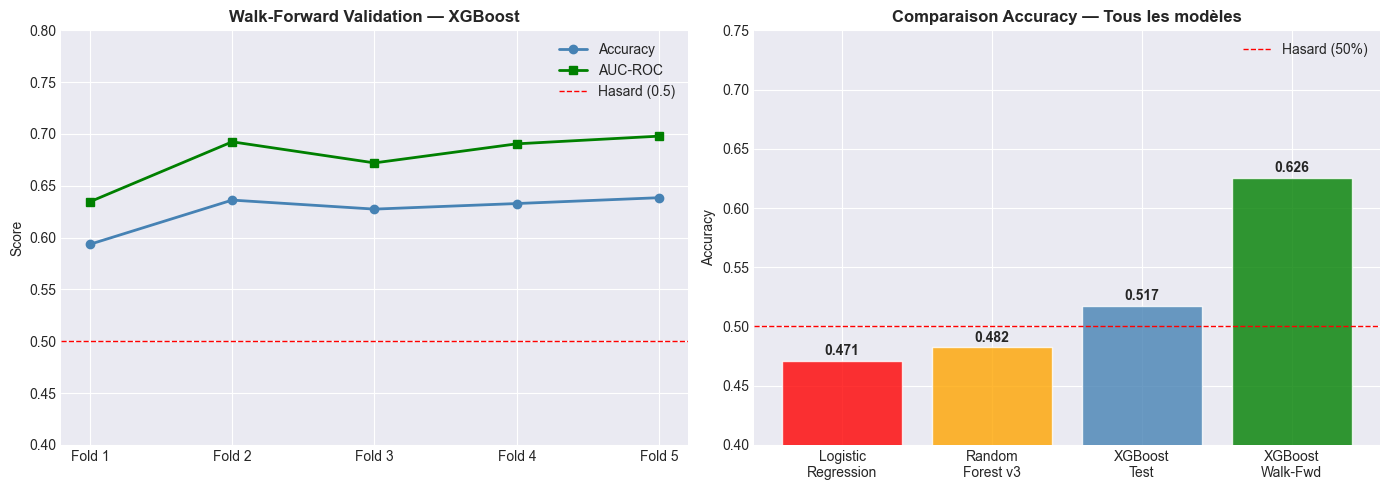

Graphique sauvegardé : plots/10_model_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds = [f'Fold {i+1}' for i in range(5)]

axes[0].plot(folds, wf_scores['accuracy'], marker='o', linewidth=2,
             color='steelblue', label='Accuracy')
axes[0].plot(folds, wf_scores['auc'], marker='s', linewidth=2,
             color='green', label='AUC-ROC')
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Hasard (0.5)')
axes[0].set_title('Walk-Forward Validation — XGBoost', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.4, 0.8)
axes[0].legend()

modeles  = ['Logistic\nRegression', 'Random\nForest v3', 'XGBoost\nTest', 'XGBoost\nWalk-Fwd']
accuracy = [acc_lr_test, acc_rf_v3_test, acc_xgb_test, np.mean(wf_scores['accuracy'])]
colors   = ['red', 'orange', 'steelblue', 'green']

bars = axes[1].bar(modeles, accuracy, color=colors, alpha=0.8, edgecolor='white')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Hasard (50%)')
axes[1].set_title('Comparaison Accuracy — Tous les modèles', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.4, 0.75)
axes[1].legend()

for bar, val in zip(bars, accuracy):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('plots/10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : plots/10_model_comparison.png')

In [18]:
predictions_df = test_df[['date', 'ticker', 'sector', 'target_return', 'target_direction']].copy()
predictions_df['xgb_pred_direction'] = y_pred_xgb_clf_test
predictions_df['xgb_pred_proba']     = y_proba_xgb_test
predictions_df['xgb_pred_return']    = y_pred_xgb_test

predictions_df.to_parquet('data/04_predictions.parquet', index=False)

print('Prédictions sauvegardées!')
print(f'  data/04_predictions.parquet ({len(predictions_df):,} lignes)')
print()
print('Notebook 04 terminé! Prochain notebook: 05_models_deep_learning.ipynb')

Prédictions sauvegardées!
  data/04_predictions.parquet (26,803 lignes)

Notebook 04 terminé! Prochain notebook: 05_models_deep_learning.ipynb



## Résumé — Ce qu'on a fait dans ce notebook

| Modèle | Accuracy Test | F1 Test | AUC Test | Overfitting |
|---|---|---|---|---|
| Linear Regression | ~47% | ~0.00 | ~0.50 | Non |
| Random Forest v1 | 47% | 0.04 | 0.49 | Oui (gap=0.25) |
| Random Forest v3 | 48% | 0.32 | 0.50 | Partiel (gap=0.10) |
| XGBoost | 52% | 0.66 | 0.50 | Non (gap=-0.01) |
| XGBoost Walk-Forward | **62.6%** | **0.676** | **0.677** | Non |

**Conclusion :** XGBoost est clairement le meilleur modèle classique. Sa régularisation explicite (L1+L2) et son early stopping lui permettent d'éviter l'overfitting là où le Random Forest échoue sur des données financières bruitées. La walk-forward validation confirme que le modèle est robuste sur différentes périodes de marché.

---
**Prochain notebook : `05_models_deep_learning.ipynb`**
On va entraîner des modèles LSTM et GRU pour capturer les dépendances temporelles longues dans les données.